In [212]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math
from scipy import stats 
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import statsmodels as sm

In [213]:
np.random.seed(42)
random.seed(42)

We will use the following properties of covariance to derive FPC(finite population correction):
$$Cov(X,Y)=E(XY)-E(X)E(Y)$$
$$Cov(A+B,C)=Cov(A,C)+Cov(B,C)$$
$$Cov(X,const)=0$$

FPC should be used when we sample without replacement and population size is small

In [214]:
#Example process
x = np.linspace(1, 10, 10)
y = np.random.choice(x, replace=False, size=3)
print(y)

[9. 2. 6.]


$$ x_1+x_2+\cdots+x_N=const \to Cov(x_1+\cdots+x_N,x_i)=0 $$
$$ Cov(x_1+\cdots+x_N,x_i)=Var(x_i)+(N-1)Cov(x_i,x_j)\:(i\ne j) $$
$$ Cov(x_i,x_j)=-\frac{Var(x_i)}{N-1}=-\frac{\sigma^2}{N-1} $$
$$ Var(\overline{x}_n)=\frac{1}{n}(Var(x_1)+\cdots+Var(x_n)+Cov(x_i,x_j))\:(for\:each\:pair\:i,j) $$
$$ =\frac{1}{n^2}\cdot(n\cdot \sigma^2+\frac{n(n-1)}{2}\cdot2(-\frac{\sigma^2}{N-1}))=(1-\frac{n-1}{N-1})\cdot\frac{\sigma^2}{n} $$

Assume that we have a deck with 2 legendary cards(denote them by 1) and 8 regular (denote them by 0). Drawing 4 cards out of the deck and calculating variance will show that this correction is useful.

In [215]:
#Deck
x = np.concatenate((np.zeros(8), np.ones(2)))

result = []
for i in range(10000):
    val = np.random.choice(x, 4, replace=False)
    result.append(val.sum())
result = np.array(result)

print("Variance:", result.var())

Variance: 0.41963324


Without correction:
$$ p=0.2\:(Probability\:of\:drawing\:legendary\:card) $$
$$\sigma^2=npq=4\cdot0.2\cdot0.8=0,64$$
With correction:
$$ 0,64\cdot\frac{10-4}{10-1}\sim 0,426 $$

NPS (Net promoter score) is a metric that is widely used to measure customer loyalty, satisfaction, and overall brand advocacy.

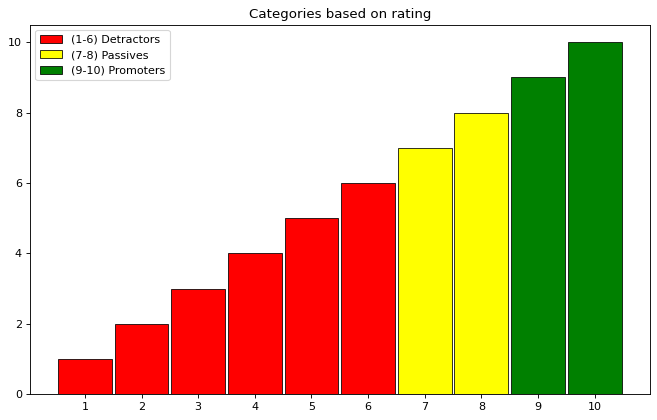

In [216]:
def plot_hist(x : np.array, col, label):
    val = []
    for i in x:
        for j in range(int(i)):
            val.append(i)
    val = np.array(val)
    plt.hist(val, bins=np.arange(0.5, 11.5, 1), color=col, label=label, 
             edgecolor='black', linewidth=0.7, rwidth=0.95)

fig, ax = plt.subplots(figsize = (10, 6), dpi=80)
plt.xticks(np.linspace(1, 10, 10))
x = np.linspace(1, 6, 6)
plot_hist(x, "red", "(1-6) Detractors")
x = np.linspace(7, 8, 2)
plot_hist(x, "yellow", "(7-8) Passives")
x = np.linspace(9, 10, 2)
plot_hist(x, "green", "(9-10) Promoters")
plt.title("Categories based on rating")
plt.legend()


$$p_{promoters} - p_l$$
$$ p_{passives (neutrals)} - p_n$$
$$ p_{detractors} - p_d$$
Now we want to find distribution of 
$$ p_l - p_d $$

First we need to notice that
$$ Cov(p_l, p_d) < 0 $$
To find covariance we can use the trick above:
$$ Cov(D + N + L, D) = 0 \:(D + N + L = n) $$

Now we can solve the system of equations to find all covariances:
$$Cov(D, D)+Cov(D, N)+Cov(D,L)=0$$
$$Cov(N,D) + Cov(N,N)+Cov(N,L)=0$$
$$Cov(L,D)+Cov(L,N)+Cov(L,L)=0$$
$$Cov(X,X)=Var(X)=p_X(1-p_X)$$

From equations above:
$$Cov(L, D)=-np_l p_d, Cov(\widehat{p}_l,\widehat{p}_d)=\frac{1}{n^2}\cdot Cov(L,D)$$

In [217]:
#100 people 1000 times

for j in range(3):
    n_respondents = 100
    n_surveys = 1000
    true_probs = [0.20, 0.30, 0.50] 

    data = np.random.multinomial(n_respondents, true_probs, size=n_surveys)
    d = data[:, 0]
    p = data[:, 2]

    cov = np.cov(d, p)
    print("var:", cov[0, 1])

var: -9.161705705705703
var: -11.368704704704705
var: -10.969456456456458


Variance is around -10 which is good

$$Cov(L, D) = n \cdot p_d \cdot p_l = -100 \cdot 0,2 \cdot 0,5 = -10$$
We can also construct CI:
$$ \widehat{p}_l-\widehat{p}_d\sim N(p_l-p_d,\frac{\widehat{p_l}(1-\widehat{p_l})}{n} + \frac{\widehat{p_d}(1-\widehat{p_d})}{n}-\frac{\widehat{p_l}\widehat{p_d}}{n}) $$

Last thing for today is the Mann-Whitney test or U-test.
$$ H_0:f_t(x)=f_c(x), H_a:f_t(t+\delta)=f_c(t)\:where\: \delta\ne0 $$

First we need to sort all values of treatment and control group then assign ranks to them. For example:

Values: [1, 2, 2, 2, 3, 4]

Ranks: [1, 3, 3, 3, 5, 6] 

we have duplicate values on positions 2, 3, 4 so their rank will be (2 + 3 + 4) / 3

Now we can calculate our criteria:
$$ U_t=\sum_{i=1}^{n_t}R_i-\frac{n_t\cdot (n_t+1)}{2} $$

In [218]:
d_lambda = 3
x_t = np.random.exponential(scale=1/d_lambda, size=5)
x_c = np.random.exponential(scale=1/d_lambda, size=5) + 0.2

For small samples we can estimate the Binomial Distribution or use normal approximation:
$$ E(U_t)=n_t \cdot E(R_i)=n_t \cdot \frac{1}{N} \cdot\frac{N(N+1)}{2}-\frac{n_t(n_t+1)}{2}=\frac{n_t\cdot n_c}{2} $$
$$ Var(U)=n_t\cdot Var(R_t)\cdot\frac{N-n_t}{N-1}(FPC) $$
$$Var(U_t)=E(U_t^2)-E(U_t^2), E(U_t^2)=\frac{1}{N}(1^2+\cdots+N^2)=\frac{1}{N}\cdot\frac{N(N+1)(2N+1)}{6}$$
$$Var(R_t)=\frac{n_t \cdot n_c(n_t+n_c+1)}{12}

This test is already implemented in scipy :D

In [219]:
d_lambda = 3
x_t = np.random.exponential(scale=1/d_lambda, size=5)
x_c = np.random.exponential(scale=1/d_lambda, size=5) + 0.21
result = stats.mannwhitneyu(x_t, x_c, alternative='two-sided')
print(f"U-stat: {result.statistic}, pval: {result.pvalue}")

U-stat: 0.0, pval: 0.007936507936507936


In [220]:
d_lambda = 3
x_t = np.random.exponential(scale=1/d_lambda, size=13)
x_c = np.random.exponential(scale=1/d_lambda, size=17) + 3
result = stats.mannwhitneyu(x_t, x_c, alternative='two-sided')
print(f"U-stat: {result.statistic}, pval: {result.pvalue}")

U-stat: 0.0, pval: 4.15064825629037e-06
